Project: Dhaka House Rent Analysis



Title: An Analysis of Rental Housing Patterns in Dhaka City

STEP 1: IMPORT & LOAD DATA

In [4]:
from google.colab import files
uploaded = files.upload()


ModuleNotFoundError: No module named 'google'

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("house_rent.csv")

# Preview
df.head()

,address,type,rent,beds,baths,sqft,Location,Area
0,"Jalalabad Housing Society, West Khulshi, 9 No....",Apartment,20000.0,3,3,"1,250",Chattogram,9 No. North Pahartali Ward
1,"Paikpara, Ahmed Nagar, Mirpur, Dhaka",Apartment,14000.0,3,2,950,Dhaka,Mirpur
2,"Paikpara, Ahmed Nagar, Mirpur, Dhaka",Apartment,13000.0,3,2,800,Dhaka,Mirpur
3,"Mohakhali DOHS, Dhaka",Apartment,45000.0,3,3,"1,350",Dhaka,Mohakhali DOHS
4,"Block C, Mansurabad Housing Society, Adabor, D...",Apartment,22000.0,3,3,"1,250",Dhaka,Adabor


STEP 2: FILTER ONLY DHAKA DATA

In [ ]:
# Check unique locations
df['Location'].unique()

# Filter only Dhaka
df_dhaka = df[df['Location'].str.contains("Dhaka", case=False, na=False)]

# Reset index
df_dhaka = df_dhaka.reset_index(drop=True)

df_dhaka.shape

(3428, 8)

STEP 3: DATA UNDERSTANDING

In [ ]:
df_dhaka.info()
df_dhaka.describe()
df_dhaka.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3428 entries, 0 to 3427
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   address   3428 non-null   object 
 1   type      3428 non-null   object 
 2   rent      3428 non-null   float64
 3   beds      3428 non-null   object 
 4   baths     3428 non-null   object 
 5   sqft      3428 non-null   object 
 6   Location  3428 non-null   object 
 7   Area      3424 non-null   object 
dtypes: float64(1), object(7)
memory usage: 214.4+ KB


,0
address,0
type,0
rent,0
beds,0
baths,0
sqft,0
Location,0
Area,4


STEP 4: DATA CLEANING

In [ ]:
# Handle Missing Values
df_dhaka = df_dhaka.dropna()

# Remove duplicates
df_dhaka.drop_duplicates(inplace=True)

# Clean 'sqft' column
# Remove non-numeric characters like commas, 'sqft', spaces
df_dhaka['sqft'] = df_dhaka['sqft'].astype(str).str.replace(r'[^0-9.]', '', regex=True)

# Convert to numeric
df_dhaka['sqft'] = pd.to_numeric(df_dhaka['sqft'], errors='coerce')

# Ensure rent is numeric (safety)
df_dhaka['rent'] = pd.to_numeric(df_dhaka['rent'], errors='coerce')

# Drop missing values in important columns
df_dhaka.dropna(subset=['rent', 'sqft'], inplace=True)

# Remove zero or invalid sqft
df_dhaka = df_dhaka[df_dhaka['sqft'] > 0]

STEP 5: REMOVE OUTLIERS (IQR)

In [ ]:
Q1 = df_dhaka['rent'].quantile(0.25)
Q3 = df_dhaka['rent'].quantile(0.75)
IQR = Q3 - Q1

df_dhaka = df_dhaka[
    (df_dhaka['rent'] >= Q1 - 1.5 * IQR) &
    (df_dhaka['rent'] <= Q3 + 1.5 * IQR)
]


STEP 6: FEATURE ENGINEERING

In [ ]:
# Feature 1: Price per sqft
df_dhaka['price_per_sqft'] = df_dhaka['rent'] / df_dhaka['sqft']

# Feature 2: Rent Category
df_dhaka['rent_category'] = pd.cut(
    df_dhaka['rent'],
    bins=[0, 20000, 50000, 100000, np.inf], # Fixed: Using np.inf to ensure monotonic bins
    labels=['Low', 'Medium', 'High', 'Luxury']
)

# Feature 3: Bedroom Group
# Convert 'beds' to numeric first
df_dhaka['beds'] = pd.to_numeric(df_dhaka['beds'], errors='coerce')
df_dhaka.dropna(subset=['beds'], inplace=True) # Drop rows where beds became NaN

df_dhaka['bedroom_group'] = pd.cut(
    df_dhaka['beds'],
    bins=[0, 2, 4, 10],
    labels=['Small', 'Medium', 'Large']
)

STEP 7: DATA ANALYSIS

In [ ]:

# Average rent by area
avg_rent_area = df_dhaka.groupby('Area')['rent'].mean().sort_values(ascending=False)
print("\nTop Areas by Average Rent:\n", avg_rent_area.head(10))

# Rent by bedroom group
rent_by_bed = df_dhaka.groupby('bedroom_group')['rent'].mean()
print("\nRent by Bedroom Group:\n", rent_by_bed)

# Correlation (Relationship)
correlation = df_dhaka[['sqft', 'rent']].corr()
print("\nCorrelation (sqft vs rent):\n", correlation)

# Top expensive locations
top_locations = df_dhaka.groupby('Area')['rent'].mean().sort_values(ascending=False).head(5)
print("\nTop 5 Expensive Areas:\n", top_locations)

# Rent distribution
print("\nRent Statistics:\n", df_dhaka['rent'].describe())

# NumPy Z-score analysis
rent_mean = np.mean(df_dhaka['rent'])
rent_std = np.std(df_dhaka['rent'])

df_dhaka['z_score'] = (df_dhaka['rent'] - rent_mean) / rent_std

extreme_values = df_dhaka[df_dhaka['z_score'] > 2]
print("\nExtreme High Rent Properties:\n", extreme_values.head())



Top Areas by Average Rent:
 Area
Banani DOHS       60000.000000
Gulshan           55000.000000
Banani            55000.000000
Baridhara         50000.000000
Lalmatia          46222.222222
Kakrail           45250.000000
Baridhara DOHS    43388.888889
Uttara            40243.421053
Shiddheswari      40222.222222
Mohakhali DOHS    37500.000000
Name: rent, dtype: float64

Rent by Bedroom Group:
 bedroom_group
Small     16726.597938
Medium    28438.973384
Large     41666.666667
Name: rent, dtype: float64

Correlation (sqft vs rent):
           sqft      rent
sqft  1.000000  0.803448
rent  0.803448  1.000000

Top 5 Expensive Areas:
 Area
Banani DOHS    60000.000000
Gulshan        55000.000000
Banani         55000.000000
Baridhara      50000.000000
Lalmatia       46222.222222
Name: rent, dtype: float64

Rent Statistics:
 count     2069.000000
mean     25731.802803
std      11269.508067
min       9000.000000
25%      17000.000000
50%      22000.000000
75%      30000.000000
max      60000.0000

/tmp/ipykernel_3506/1941732140.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rent_by_bed = df_dhaka.groupby('bedroom_group')['rent'].mean()


STEP 8: VISUALIZATION

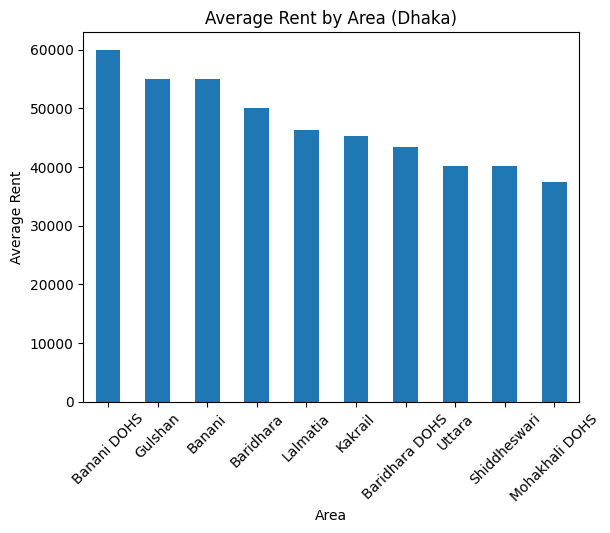

In [ ]:

# Bar chart
top_areas = avg_rent_area.head(10)

top_areas.plot(kind='bar')
plt.title("Average Rent by Area (Dhaka)")
plt.xlabel("Area")
plt.ylabel("Average Rent")
plt.xticks(rotation=45)
plt.show()



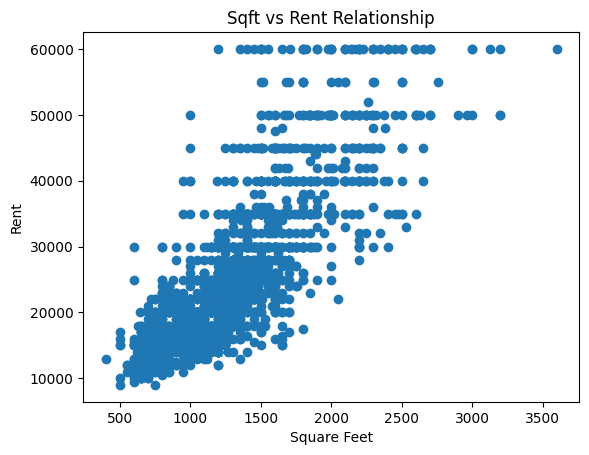

In [ ]:
# Scatter plot
plt.scatter(df_dhaka['sqft'], df_dhaka['rent'])
plt.title("Sqft vs Rent Relationship")
plt.xlabel("Square Feet")
plt.ylabel("Rent")
plt.show()


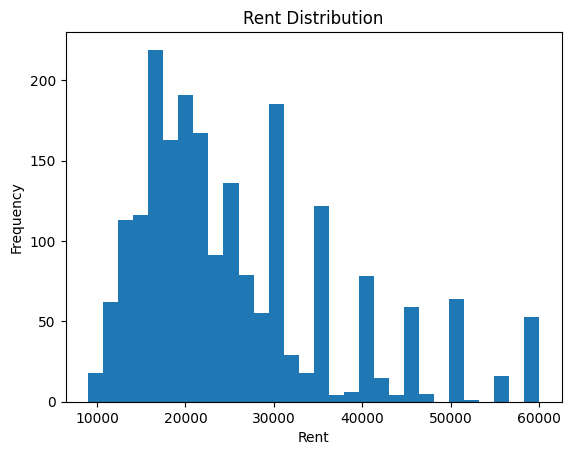

In [ ]:

# Histogram
plt.hist(df_dhaka['rent'], bins=30)
plt.title("Rent Distribution")
plt.xlabel("Rent")
plt.ylabel("Frequency")
plt.show()



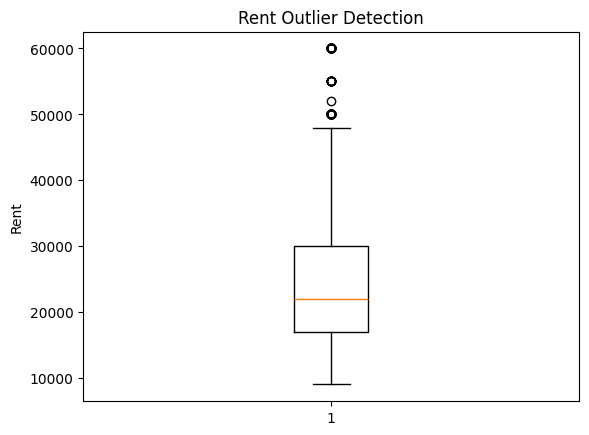

In [ ]:
# Boxplot
plt.boxplot(df_dhaka['rent'])
plt.title("Rent Outlier Detection")
plt.ylabel("Rent")
plt.show()